# Calibration — traffic flows + edge weights

Showcase notebook — a self-contained demo of two `aperta` primitives
in the sequence they compose in production: **traffic-flow estimation
feeds edge-weight calibration**. Concretely, we

1. fetch the Canton of Zurich car network from OpenStreetMap,
2. estimate per-edge AADT (`aperta.traffic_flows`) via
   nested-betweenness sampling with a survey-derived target cost
   distribution,
3. compute a per-edge congestion feature `vc_beta_2 =
   (flow_estimate / capacity)²`, and
4. calibrate per-edge durations (`aperta.calibration.calibrate_edge_weights`)
   against observed peak-hour travel times, with `vc_beta_2` as a
   multiplier feature alongside `density_norm` and `is_traffic_signal`.

The point of consolidating the two demos into one notebook is exactly
this composition: flows in isolation produce a number that goes
nowhere; edge weights in isolation ignore congestion. Together they
tell one story — which is how aperta-atlas's production pipeline is
structured (`main/04b_traffic_flows.py` → `main/05_edge_weights.py`).

> ⚠️ **Data availability.** Only ground truth is proprietary: Swiss
> ASTRA traffic-counter readings (`traffic_counters.gpkg`) and
> Google-Maps-derived car travel times (`travel_times_car_peak.csv`),
> both under `<APERTA_EXAMPLES_GROUND_TRUTH_DIR>` (default
> `../data/ground_truth`). aperta cannot redistribute these under
> their source terms — cells past §1 will not run without them.
> A synthetic public version is planned.
>
> **Not a full pipeline.** For a production calibration on richer
> prepared inputs (population-derived trip generation from a calibrated
> Poisson GLM, calibrated cost-distribution bin edges, BPR capacity
> model, per-time-of-day fits, transferable coefficients), see
> [aperta-atlas](https://github.com/mmiotti/aperta-atlas)'s
> `main/04b_traffic_flows.py` + `main/05_edge_weights.py`.

## Approach at a glance

**Two per-edge features derived inline from raw OSM:**

- **`is_traffic_signal`** — per edge, `1` if EITHER endpoint node has
  the raw OSM tag `highway=traffic_signals`, else `0`.
- **`density_norm`** — per edge, mean of the per-node density at its
  two endpoints. Per-node density is `KDTree`-counted neighbours
  within `DENSITY_RADIUS_M` metres, normalised to `[0, 1]`. A network
  proxy for local intersection density; correlates with population
  density in canton-scale study areas but doesn't require dasymetric-
  mapped population data.

**Two simplifications carried over from the standalone flow demo.**
No stochastic routing — every OD pair takes a single deterministic
shortest path. No capacity-based slowdown in the flow model itself —
saturated and empty motorways carry the same edge weight during
sampling. Net effect: over-prediction on highways / main roads,
under-prediction on parallel local roads. That's acceptable for a
*relative* congestion feature (what enters edge_weight calibration
via `vc_beta_2`); it's not acceptable for road design.

**Cost-distribution target.** Each origin's sampled trip costs are
reweighted to match a target P(C) read directly from the ground-truth
Google-Maps trip times — equal-probability percentile bins over
`[MIN_COST_S, MAX_COST_S]`. `bin_adjusted_dest_weights` does the
reweighting; `nested_node_sample` then draws destinations proportional
to the adjusted weights.

**Cell + zone hierarchy.** Origins and short-trip destinations use
H3-res-10 cells (~130 m); medium- and far-tier destinations aggregate
to H3-res-8 zones (~460 m). Cell-level origins matter because
intra-zone short trips contribute disproportionately to local-road
flows.

**Building-based trip generation.** Each cell counts the OSM building
centroids falling in it (`n_buildings`), then applies a
Poisson-GLM-shaped rescaling with a density interaction:
    trip_weight ≈ (1 + n_buildings)^(LOG_BLDG_COEF + DENSITY_INTERACTION_COEF · density)
The shape mirrors aperta-atlas 04a's calibrated GLM (log1p(pop) +
log1p(emp) with density interactions); we substitute `n_buildings` for
the calibrated (pop, emp) pair and hand-pick the exponents.

In [1]:
import os
import warnings
from pathlib import Path

import geopandas as gpd
import h3
import matplotlib.pyplot as plt
import numpy as np
import osmnx as ox
import pandas as pd
from shapely.geometry import Polygon
from sklearn.neighbors import KDTree

from aperta import (
    calibration,
    geo_processing,
    network_processing,
    network_snap,
    od_pairs,
    routing,
    routing_prep,
    traffic_flows,
)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='geopandas')

# OSM highway-tier rank dict — inlined in `_figures.py` to keep aperta
# examples standalone (aperta is OSM-agnostic; rank conventions are
# owned by aperta-atlas, which we don't import from in aperta's notebooks).
import _figures as figures  # noqa: E402  — project-local plot helpers

OSM_HIGHWAY_RANKS = figures.OSM_HIGHWAY_RANKS

## Parameters

Everything tunable in one place.

In [2]:
# Ground truth (proprietary). Override with APERTA_EXAMPLES_GROUND_TRUTH_DIR.
GROUND_TRUTH_DIR = Path(os.environ.get(
    'APERTA_EXAMPLES_GROUND_TRUTH_DIR', '../data/ground_truth'))
GROUND_TRUTH_LEGS = GROUND_TRUTH_DIR / 'travel_times_car_peak.csv'
GROUND_TRUTH_COUNTERS = GROUND_TRUTH_DIR / 'traffic_counters.gpkg'

# Area + CRS. `Kanton Zürich` (~1,700 km²) is much larger than the city
# — Nominatim's default match for the bare "Zurich, Switzerland" would
# return the Gemeinde (admin_level=8, ~92 km²); the explicit "Kanton
# Zürich" name resolves to the canton (admin_level=4).
PLACE = 'Kanton Zürich, Switzerland'
LOCATION_LABEL = 'Zurich'
CRS_METRIC = 'EPSG:2056'  # LV95 (Swiss metric)
H3_RES_CELLS = 10          # ~130 m hex edge
H3_RES_ZONES = 8           # ~460 m hex edge (parent-child = single H3 call)
DENSITY_RADIUS_M = 500.0   # for the per-edge `density_norm` feature

# Counter-to-edge snap. Highway counters get a wider radius (sparser
# layout, lower risk of catching a parallel local road) but can only
# snap to highway edges. Bearing tolerance prevents opposite-direction
# counters from cross-snapping on two-way roads.
HIGHWAY_RADIUS_M = 25.0
NON_HIGHWAY_RADIUS_M = 10.0
BEARING_TOL_DEG = 20.0

# Initial per-edge durations for flow estimation:
# base = INITIAL_BASELINE_MULT · length / speed_kph, with multiplicative
# + additive corrections for density + signal load on top. The baseline
# multiplier > 1 encodes the average "slower than posted limit" effect
# from intersections / curves / minor bottlenecks not otherwise captured
# by the two feature-based corrections. Off-peak car priors; the
# flow-aware edge calibration in §5 replaces these with fitted values.
INITIAL_BASELINE_MULT = 1.2
INITIAL_MULT = {'density_norm': 1.0}
INITIAL_ADD = {'is_traffic_signal': 5.0}

# OD-tier radii (CRS metres) + travel-time cutoff.
R_CELLS_M = 1_500
R_MEDIUM_M = 10_000
R_ZONES_M = 100_000
# Cutoff at 60 min: the study area doesn't systematically allow for
# longer trips than that; a wider cutoff biases the sample.
CAR_TIME_CUTOFF_S = 3600

# Study-area extents — two concentric polygons, derived in §1
# from the polygon for `PLACE`:
#   INNER = the polygon (verbatim) → evaluation +
#     calibration domain. Used to filter traffic counters (evaluation)
#     AND ground-truth trip legs (calibration). Flows near the
#     boundary aren't fully reliable — traffic to/from outside the
#     model isn't captured — but for a demo this is the honest scope
#     without cascading buffers.
#   OUTER = inner + NETWORK_BUFFER_M → OSM downloads
#     (network + buildings) + H3 cell grid. Extra network beyond the
#     evaluation domain lets border-crossing routes finish properly
#     instead of dead-ending at the boundary.
NETWORK_BUFFER_M = 20_000.0

# Sampling. Origins drawn trip_weight-weighted (with replacement, then
# deduped); destinations drawn per-origin proportional to the
# bin-adjusted weights (§3).
N_ORIG = 20_000
N_DEST = 50
RNG_SEED = 42

# Cost-distribution target P(C). `N_BINS` is the granularity of the
# percentile-binned target (20 ≙ 5%-bins). `MIN_COST_S` / `MAX_COST_S`
# trim the survey to a plausible trip-time window — they become the 0th
# and 100th percentiles of the target distribution.
N_BINS = 20
MIN_COST_S = 0.0
MAX_COST_S = 3600.0   # 1 h - covers most survey trips

# Volume scaling. Rough hand-wavy prior: on average ~3 vehicle-trips per
# building per day (mix of residential + commercial). Production fits
# this against observed counters.
TRIPS_PER_BUILDING_PER_DAY = 3.0

# Trip-generation weight per cell — analogous in shape to aperta-atlas 04a's
# calibrated Poisson GLM (log1p(pop) + log1p(emp) with density interactions),
# hand-picked in magnitude here:
#   trip_weight = (1 + n_buildings)^(LOG_BLDG_COEF + DENSITY_INTERACTION_COEF · density_norm)
LOG_BLDG_COEF = 1.0             # log-linear scaling in building count
DENSITY_INTERACTION_COEF = 0.5  # extra scaling in denser (more urban) cells

# BPR capacity per lane (veh/day per lane) by road tier — daily-equivalent
# of textbook hourly capacities scaled to typical AADT loading. Used to
# compute `vc = flow / capacity`, which becomes the flow-aware feature
# `vc_beta_2 = vc²` in edge-weight calibration.
CAP_PER_LANE_HIGHWAY = 30_000.0   # motorway, trunk
CAP_PER_LANE_MAIN    = 15_000.0   # primary, secondary, tertiary
CAP_PER_LANE_LOCAL   = 10_000.0   # residential, unclassified, ...
VC_BETA_EXPONENT     = 2.0        # BPR standard is β ≈ 4 for saturated flows;
                                  # β=2 fits better empirically on Swiss data
                                  # (calibration coefficient absorbs residual).

## 1. Study-area polygons + OSM network + ground truth

Three concentric polygons anchor the model (see the Parameters
section for the semantic split). Then one OSMnx call each for the
car network + buildings, plus two per-edge features
(`is_traffic_signal` + `density_norm`) derived inline. Features
enter BOTH the flow-estimation step (as prior duration adjustments)
AND the edge-weight calibration below. Ground-truth files load
here too; both get spatially filtered to the appropriate polygon.

In [3]:
# --- Fetch place boundary + compute the two polygons (in LV95).
_boundary_ll = ox.geocode_to_gdf(PLACE).dissolve()
inner_polygon = _boundary_ll.to_crs(CRS_METRIC).geometry.iloc[0]
outer_polygon = inner_polygon.buffer(NETWORK_BUFFER_M)
# OSMnx polygon-based fetches want WGS84.
outer_polygon_ll = gpd.GeoSeries(
    [outer_polygon], crs=CRS_METRIC).to_crs('EPSG:4326').iloc[0]
print(f"Study-area polygons (km²): "
      f"inner {inner_polygon.area / 1e6:,.0f}  |  "
      f"outer (+ {NETWORK_BUFFER_M/1000:.0f} km) {outer_polygon.area / 1e6:,.0f}")

# --- OSM car network over the OUTER polygon (place + NETWORK_BUFFER_M).
# Skip node consolidation (`simplify=True` only merges collinear
# geometry): consolidation would collapse groups of traffic-signal
# nodes into one, distorting the "either endpoint has a signal" test.
car_graph = ox.graph_from_polygon(
    outer_polygon_ll, network_type='drive', simplify=True)
car_graph = ox.project_graph(car_graph, to_crs=CRS_METRIC)
# Populate per-edge `speed_kph` from OSM `maxspeed` + per-highway fallback,
# matching what aperta-atlas's `preparation/world/osm/networks_decorate.py` does.
ox.add_edge_speeds(car_graph)
print(f"Car graph: {car_graph.number_of_nodes():,} nodes / "
      f"{car_graph.number_of_edges():,} edges")

# --- is_traffic_signal (raw OSM tag on nodes) → OR over edge endpoints.
for _, d in car_graph.nodes(data=True):
    d['is_traffic_signal'] = int(d.get('highway') == 'traffic_signals')
for u, v, k, d in car_graph.edges(keys=True, data=True):
    d['is_traffic_signal'] = int(
        car_graph.nodes[u]['is_traffic_signal']
        or car_graph.nodes[v]['is_traffic_signal'])

# --- density_norm: per-node KDTree count within DENSITY_RADIUS_M → normalise → mean of edge endpoints.
_node_ids = list(car_graph.nodes)
_xy = np.array([[car_graph.nodes[n]['x'], car_graph.nodes[n]['y']] for n in _node_ids])
_counts = KDTree(_xy).query_radius(_xy, r=DENSITY_RADIUS_M, count_only=True)
_density = _counts / max(_counts.max(), 1)
for n, dens in zip(_node_ids, _density):
    car_graph.nodes[n]['density_norm'] = float(dens)
for u, v, k, d in car_graph.edges(keys=True, data=True):
    d['density_norm'] = 0.5 * (
        car_graph.nodes[u]['density_norm']
        + car_graph.nodes[v]['density_norm'])

# Mode-aware preparation: keeps the graph directed (car defaults),
# precomputes the largest strongly connected component as the
# snap-eligible node set.
car_prepared = routing_prep.prepare_network(car_graph, 'car')
car_graph = car_prepared.graph
print(f"  Snap-eligible (largest SCC): {len(car_prepared.snap_eligible_nodes):,} nodes "
      f"({100 * len(car_prepared.snap_eligible_nodes) / car_graph.number_of_nodes():.1f}%)")

speeds = np.array([float(d['speed_kph'])
                   for _, _, d in car_graph.edges(data=True)])
print(f"Baseline car edge speeds: median {np.median(speeds):.0f} km/h, "
      f"range {speeds.min():.0f}–{speeds.max():.0f} km/h.")

# --- Ground-truth trip legs — filter to INNER polygon (both endpoints).
_legs_all = pd.read_csv(GROUND_TRUTH_LEGS)
_orig_pts = gpd.GeoSeries(
    gpd.points_from_xy(_legs_all['orig_x'], _legs_all['orig_y']), crs=CRS_METRIC)
_dest_pts = gpd.GeoSeries(
    gpd.points_from_xy(_legs_all['dest_x'], _legs_all['dest_y']), crs=CRS_METRIC)
_both_in = _orig_pts.within(inner_polygon).values & _dest_pts.within(inner_polygon).values
legs = _legs_all.loc[_both_in].copy()
print(f"Ground-truth legs (both endpoints in inner polygon): "
      f"{len(legs):,} of {len(_legs_all):,} "
      f"— median time {legs['time_measured'].median():.0f} s, "
      f"median dist {legs['dist_measured'].median():.0f} m")

# --- Traffic counters — filter to the INNER polygon.
# `.to_crs(CRS_METRIC)` is load-bearing: geopandas `.within()` doesn't
# auto-reproject, so mismatched CRS would silently return False for
# every counter and yield an empty evaluation set.
counters_all = gpd.read_file(GROUND_TRUTH_COUNTERS).to_crs(CRS_METRIC)
_ct_in = counters_all.geometry.within(inner_polygon)
counters = counters_all[_ct_in].copy()
print(f"Counters (all Switzerland → inside inner polygon): "
      f"{len(counters):,} of {len(counters_all):,} "
      f"(highway: {int(counters['is_highway'].sum()):,}, "
      f"main: {int(counters['is_main'].sum()):,}, "
      f"local: {int(counters['is_local'].sum()):,})")

Study-area polygons (km²): inner 1,729  |  outer (+ 20 km) 6,581
Car graph: 91,125 nodes / 216,801 edges
  Snap-eligible (largest SCC): 90,889 nodes (99.7%)
Baseline car edge speeds: median 34 km/h, range 10–120 km/h.
Ground-truth legs (both endpoints in inner polygon): 3,869 of 49,773 — median time 667 s, median dist 5149 m
Counters (all Switzerland → inside inner polygon): 832 of 4,691 (highway: 55, main: 725, local: 52)


## 2. Build cells + zones + trip-generation weight

H3 hex grids covering the OUTER polygon (inner + NETWORK_BUFFER_M);
OSM building centroids (also fetched over the OUTER polygon) assigned
to cells give `n_buildings`; a Poisson-GLM-shaped rescaling gives
per-cell `trip_weight`.

In [4]:
cells = geo_processing.build_h3_grid(
    outer_polygon_ll, H3_RES_CELLS,
    polygon_crs='EPSG:4326', target_crs=CRS_METRIC,
)
# H3's parent-child relationship gives the cell→zone assignment for free.
cells['zone_id'] = [h3.cell_to_parent(c, H3_RES_ZONES) for c in cells.index]
zone_ids = sorted(cells['zone_id'].unique())
zones = gpd.GeoDataFrame(
    {'geometry': [Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(z)])
                  for z in zone_ids]},
    index=pd.Index(zone_ids, name='zone_id'),
    crs='EPSG:4326',
).to_crs(CRS_METRIC)

# OSM building footprints → per-cell count as the trip-generation proxy.
_b = ox.features_from_polygon(outer_polygon_ll, tags={'building': True})
_b = _b[_b.geometry.type.isin(['Polygon', 'MultiPolygon'])][['geometry']].to_crs(CRS_METRIC)
_b_ll = _b.geometry.centroid.to_crs('EPSG:4326')
_building_cells = [h3.latlng_to_cell(y, x, H3_RES_CELLS)
                   for x, y in zip(_b_ll.x, _b_ll.y)]
cells['n_buildings'] = pd.Series(_building_cells).value_counts().reindex(
    cells.index, fill_value=0).astype(int)
zones['n_buildings'] = cells.groupby('zone_id')['n_buildings'].sum().reindex(
    zones.index, fill_value=0).astype(int)

# Snap cells + zones to nearest snap-eligible car-graph node.
cells['node_id'], _ = network_snap.snap_to_network_nodes(
    gpd.GeoDataFrame(geometry=cells.geometry.centroid, index=cells.index, crs=cells.crs),
    car_graph, eligible_node_ids=car_prepared.snap_eligible_nodes)
zones['node_id'], _ = network_snap.snap_to_network_nodes(
    gpd.GeoDataFrame(geometry=zones.geometry.centroid, index=zones.index, crs=zones.crs),
    car_graph, eligible_node_ids=car_prepared.snap_eligible_nodes)

# Drop unsnappable cells / zones + cells whose parent zone dropped out;
# drop cells with 0 buildings (no trip generation).
cells = cells.dropna(subset=['node_id']).copy()
zones = zones.dropna(subset=['node_id']).copy()
cells['node_id'] = cells['node_id'].astype(int)
zones['node_id'] = zones['node_id'].astype(int)
cells = cells[cells['zone_id'].isin(zones.index)].copy()
cells = cells[cells['n_buildings'] > 0].copy()

# Per-cell density from the snap node (same values used for the edge
# `density_norm` feature above); modifier in the trip-generation weight.
cells['density_norm'] = cells['node_id'].map(
    lambda n: car_graph.nodes[n]['density_norm'])
_log_bldg = np.log1p(cells['n_buildings'].astype(float))
cells['trip_weight'] = np.exp(
    LOG_BLDG_COEF * _log_bldg
    + DENSITY_INTERACTION_COEF * _log_bldg * cells['density_norm'])
# Zones aggregate additively from cells (lookup_dest_column_node conservation invariant).
zones['trip_weight'] = cells.groupby('zone_id')['trip_weight'].sum().reindex(
    zones.index, fill_value=0.0)

total_buildings = int(cells['n_buildings'].sum())
print(f"Cells: {len(cells):,} (with buildings)  |  "
      f"Zones: {len(zones):,}  |  "
      f"Σ n_buildings: {total_buildings:,}")
print(f"  trip_weight per cell: "
      f"median {cells['trip_weight'].median():.1f}, "
      f"P95 {cells['trip_weight'].quantile(0.95):.1f}")

# (Counters are already filtered to the canton polygon in §1;
# `counters` is available for use downstream.)

Cells: 122,518 (with buildings)  |  Zones: 9,489  |  Σ n_buildings: 829,315
  trip_weight per cell: median 5.1, P95 37.3


## 3. Estimate per-edge traffic flows

Prior edge durations → tiered OD pairs → shortest-path costs →
nested-betweenness sampling with a survey-derived target cost
distribution P(C) → scale counts to AADT. The final output is
`flow_estimate` on each edge, which we then normalize by lane
capacity into `vc_beta_2` — the flow-aware feature that enters §5's
edge-weight calibration.

In [5]:
# --- Snap counters to the car-graph edges (per-tier eligibility filter).
def _edge_rank_and_tier(d) -> tuple[int, str]:
    hwy = d.get('highway')
    if isinstance(hwy, list):
        hwy = hwy[0] if hwy else None
    rank = OSM_HIGHWAY_RANKS.get(hwy, -1)
    if rank >= 6:
        tier = 'highway'    # motorway / trunk
    elif rank >= 3:
        tier = 'main'       # primary / secondary / tertiary
    else:
        tier = 'local'      # residential / service / unknown
    return rank, tier

for _, _, _, d in car_graph.edges(keys=True, data=True):
    d['_highway_rank'], d['_tier'] = _edge_rank_and_tier(d)

max_distance = counters['is_highway'].map(
    {1: HIGHWAY_RADIUS_M, 0: NON_HIGHWAY_RADIUS_M})

def _eligible_for_counter(counter_row, candidate_edges):
    if counter_row['is_highway']:
        wanted = 'highway'
    elif counter_row['is_main']:
        wanted = 'main'
    else:
        wanted = 'local'
    return candidate_edges[candidate_edges['_tier'] == wanted]

snapped = calibration.snap_counters_to_edges(
    counters, car_graph,
    max_distance=max_distance,
    bearing_tol_deg=BEARING_TOL_DEG,
    eligible_edges=_eligible_for_counter,
)
counters = counters.join(snapped)
counters['highway_rank'] = [
    car_graph[u][v][k]['_highway_rank'] if pd.notna(u) else np.nan
    for u, v, k in zip(counters['u'], counters['v'], counters['k'])
]
n_matched = counters['u'].notna().sum()
print(f"Counters snapped: {n_matched:,}/{len(counters):,} "
      f"({n_matched / max(len(counters), 1) * 100:.1f}%)")

Counters snapped: 755/832 (90.7%)


In [6]:
# --- Prior per-edge durations for sampling.
KMH_TO_MS = 1.0 / 3.6
for u, v, k, d in car_graph.edges(keys=True, data=True):
    base = float(d['length']) / (float(d['speed_kph']) * KMH_TO_MS) * INITIAL_BASELINE_MULT
    mult_term = base * sum(c * float(d[f]) for f, c in INITIAL_MULT.items())
    add_term = sum(c * float(d[f]) for f, c in INITIAL_ADD.items())
    d['duration_initial'] = max(base + mult_term + add_term, base * 0.2)

# --- Tiered OD pairs + per-pair routing costs. Symmetric `trip_weight`
# at origin and destination (matches aperta-atlas 04b's convention).
pairs = od_pairs.get_pairs(
    cells, r_cells=R_CELLS_M, node_column='node_id',
    zones=zones, r_zones=R_ZONES_M, r_medium=R_MEDIUM_M,
)
costs = routing.tiered_path_costs(car_graph, pairs, weight='duration_initial', cutoff=CAR_TIME_CUTOFF_S,
)
orig_weights = od_pairs.node_values(
    'trip_weight', cells, list(pairs.cells_to_cells.keys()))
dest_weights = od_pairs.lookup_dest_column_node(
    'trip_weight', pairs, cells, zones=zones)
cell_to_zone_node = od_pairs.build_cell_to_zone_node_map(cells, zones)

# --- Cost-distribution target P(C). Survey trip times trimmed to
# [MIN_COST_S, MAX_COST_S]; equal-probability percentile bins over the
# in-range subset become the target each origin is rescaled to match.
_survey_costs = legs.loc[
    (legs['time_measured'] >= MIN_COST_S)
    & (legs['time_measured'] <= MAX_COST_S),
    'time_measured',
].to_numpy()
bin_edges = traffic_flows.percentile_bin_edges(_survey_costs, n_bins=N_BINS)
bin_edges[0] = MIN_COST_S
bin_edges[-1] = MAX_COST_S
print(f"Cost-bin edges ({N_BINS} bins over "
      f"[{MIN_COST_S:.0f}, {MAX_COST_S:.0f}] s, "
      f"n_survey={len(_survey_costs):,}):")
print(f"  {[f'{e:.0f}' for e in bin_edges]}")

adjusted_dest_weights = traffic_flows.bin_adjusted_dest_weights(
    pairs, costs, dest_weights, bin_edges,
)

# --- Sample origins + destinations; accumulate edge betweenness; scale to AADT.
rng = np.random.RandomState(RNG_SEED)
nested_sample = traffic_flows.nested_node_sample(
    pairs=pairs, weights=adjusted_dest_weights, costs=costs,
    cell_to_zone_node=cell_to_zone_node, orig_weights=orig_weights,
    cost_to_weight=np.ones_like, n_orig=N_ORIG, n_dest=N_DEST,
    random_state=rng,
)
edge_bc = network_processing.get_nested_edge_betweenness(
    car_graph, nested_sample, weight='duration_initial',
    cutoff=od_pairs.max_cost(costs),
)
aadt_scale = (total_buildings * TRIPS_PER_BUILDING_PER_DAY) / (len(nested_sample) * N_DEST)
flows = edge_bc * aadt_scale
network_processing.set_nx_edge_attributes_filled(
    car_graph, flows.to_dict(), 'flow_estimate', fill_value=0.0)
print(f"flows (veh/day): median {flows.median():.0f}, "
      f"P95 {flows.quantile(0.95):.0f}, max {flows.max():.0f}")

# --- Evaluate flows against counters (sanity check before using them
# as an edge-weight feature).
ev_flows = calibration.evaluate_against_counters(flows, counters)
print(f"Fit at counters: R²={ev_flows['r2']:.3f}, "
      f"slope={ev_flows['slope']:.3f}, "
      f"RMSE={ev_flows['rmse']:.0f}, "
      f"n={ev_flows['n_matched']:,}")

Cost-bin edges (20 bins over [0, 3600] s, n_survey=3,845):
  ['0', '145', '195', '245', '288', '336', '387', '447', '507', '582', '661', '754', '836', '942', '1061', '1195', '1372', '1578', '1876', '2275', '3600']
flows (veh/day): median 232, P95 3613, max 38231
Fit at counters: R²=0.788, slope=0.556, RMSE=5109, n=754


In [7]:
# --- Compute vc_beta = (flow/capacity)^β per edge. Capacity depends on
# road tier + number of lanes; β=2 balances well against typical
# Swiss-network fit sensitivity.
def _capacity_per_lane(d) -> float:
    """Textbook hourly capacity per lane, daily-equivalent."""
    hwy = d.get('highway')
    if isinstance(hwy, list):
        hwy = hwy[0] if hwy else None
    rank = OSM_HIGHWAY_RANKS.get(hwy, -1)
    if rank >= 6:
        return CAP_PER_LANE_HIGHWAY
    if rank >= 3:
        return CAP_PER_LANE_MAIN
    return CAP_PER_LANE_LOCAL

for u, v, k, d in car_graph.edges(keys=True, data=True):
    lanes = float(d.get('lanes_per_direction') or 1) or 1.0
    cap = _capacity_per_lane(d) * max(lanes, 1.0)
    flow = float(d.get('flow_estimate', 0.0))
    vc = flow / cap if cap > 0 else 0.0
    d['capacity'] = cap
    d['vc'] = vc
    d['vc_beta_2'] = vc ** VC_BETA_EXPONENT

_vc = np.array([float(d['vc']) for _, _, d in car_graph.edges(data=True)])
_vc_beta = np.array([float(d['vc_beta_2']) for _, _, d in car_graph.edges(data=True)])
print(f"vc (flow/capacity):   median {np.median(_vc):.3f}, "
      f"P95 {np.quantile(_vc, 0.95):.3f}, max {_vc.max():.3f}")
print(f"vc_beta_2 = vc^{VC_BETA_EXPONENT:.0f}:  median {np.median(_vc_beta):.4f}, "
      f"P95 {np.quantile(_vc_beta, 0.95):.4f}, max {_vc_beta.max():.4f}")

vc (flow/capacity):   median 0.009, P95 0.206, max 1.483
vc_beta_2 = vc^2:  median 0.0001, P95 0.0423, max 2.1983


## 4. Traffic flow parameter calibration

The trip-generation weight `(1 + n_buildings)^(LOG_BLDG_COEF +
DENSITY_INTERACTION_COEF · density_norm)` embeds one hand-picked
knob: how much *more* trips per building dense (urban) cells emit
than sparse (rural) ones. Production would coordinate-descent this
alongside the calibration coefficients; here we sweep it in isolation
to see what the response surface looks like.

The expensive step in §3 (`routing.tiered_path_costs` — Dijkstra
over every OD pair) does *not* depend on `DENSITY_INTERACTION_COEF`,
so we reuse `pairs`, `costs`, `cell_to_zone_node`, and `bin_edges`
across the sweep. Only trip-weight recomputation, nested sampling,
and betweenness accumulation run per iteration.

In [8]:
COEF_SWEEP = [-0.5, 0.0, 0.5, 1.0, 1.5]


def _estimate_flows(coef: float) -> dict:
    """Recompute flows for a given `DENSITY_INTERACTION_COEF`.
    Reuses `pairs`, `costs`, `cell_to_zone_node`, `bin_edges` from §3."""
    _log = np.log1p(cells['n_buildings'].astype(float))
    tw = np.exp(LOG_BLDG_COEF * _log + coef * _log * cells['density_norm'])
    cells_c = cells.assign(trip_weight=tw)
    zones_c = zones.assign(
        trip_weight=cells_c.groupby('zone_id')['trip_weight'].sum()
        .reindex(zones.index, fill_value=0.0))
    ow = od_pairs.node_values(
        'trip_weight', cells_c, list(pairs.cells_to_cells.keys()))
    dw = od_pairs.lookup_dest_column_node(
        'trip_weight', pairs, cells_c, zones=zones_c)
    adj = traffic_flows.bin_adjusted_dest_weights(pairs, costs, dw, bin_edges)
    rng = np.random.RandomState(RNG_SEED)
    sample = traffic_flows.nested_node_sample(
        pairs=pairs, weights=adj, costs=costs,
        cell_to_zone_node=cell_to_zone_node, orig_weights=ow,
        cost_to_weight=np.ones_like, n_orig=N_ORIG, n_dest=N_DEST,
        random_state=rng)
    bc = network_processing.get_nested_edge_betweenness(
        car_graph, sample, weight='duration_initial',
        cutoff=od_pairs.max_cost(costs))
    scale = (total_buildings * TRIPS_PER_BUILDING_PER_DAY) / (len(sample) * N_DEST)
    ev = calibration.evaluate_against_counters(bc * scale, counters)
    nrmse = ev['rmse'] / ev['merged']['observed'].mean()
    return {'coef': coef, 'r2': ev['r2'], 'nrmse': nrmse, 'n': ev['n_matched']}


sweep = pd.DataFrame([_estimate_flows(c) for c in COEF_SWEEP])
print(sweep.to_string(index=False))

 coef       r2    nrmse   n
 -0.5 0.746145 0.873987 755
  0.0 0.769436 0.831832 755
  0.5 0.788033 0.770664 754
  1.0 0.740434 0.711470 755
  1.5 0.619856 0.835267 753


Saved results/figures_highres/density_interaction_sweep.pdf


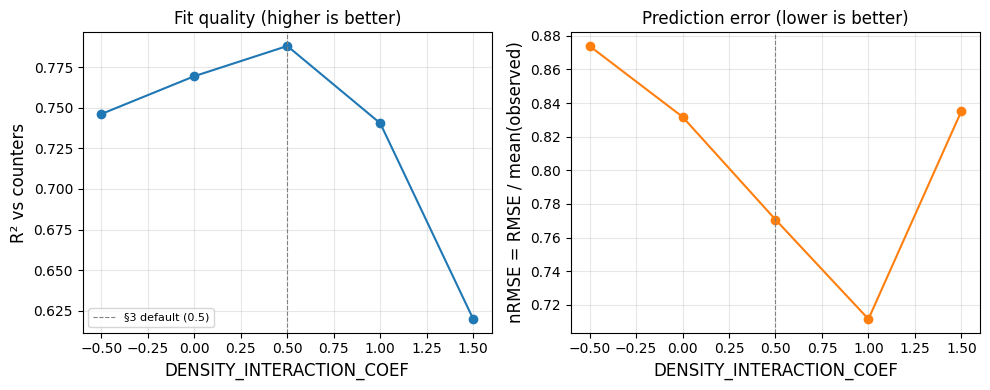

In [9]:
fig, (ax_r2, ax_nrmse) = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

ax_r2.plot(sweep['coef'], sweep['r2'], marker='o', color='tab:blue')
ax_r2.axvline(DENSITY_INTERACTION_COEF, linestyle='--', color='gray',
              linewidth=0.8, label=f'§3 default ({DENSITY_INTERACTION_COEF})')
ax_r2.set_xlabel('DENSITY_INTERACTION_COEF')
ax_r2.set_ylabel('R² vs counters')
ax_r2.set_title('Fit quality (higher is better)')
ax_r2.legend(loc='lower left', fontsize=8)
ax_r2.grid(True, alpha=0.3)

ax_nrmse.plot(sweep['coef'], sweep['nrmse'], marker='o', color='tab:orange')
ax_nrmse.axvline(DENSITY_INTERACTION_COEF, linestyle='--', color='gray',
                 linewidth=0.8)
ax_nrmse.set_xlabel('DENSITY_INTERACTION_COEF')
ax_nrmse.set_ylabel('nRMSE = RMSE / mean(observed)')
ax_nrmse.set_title('Prediction error (lower is better)')
ax_nrmse.grid(True, alpha=0.3)

plt.tight_layout()
figures.save_figure(fig, 'density_interaction_sweep', ext='pdf')
plt.show()

## 5. Flow-aware edge-weight calibration

Same `aperta.calibration.calibrate_edge_weights` primitive as
`edge_weights.ipynb` used, but now the multiplier features include
`vc_beta_2` — a per-edge congestion index derived from the flow
estimate. The idea: intersection-only and density-only features
capture *where* travel time is slower in the abstract; `vc_beta_2`
captures *why* it's slower under peak load. In practice, adding it
closes the gap on congested motorway / main-road links that pure
geometry-based features miss.

Three feature groups enter the OLS fit:

- **multiplier**: scales baseline duration. `coef · baseline ·
  feature_value`. `density_norm` + `vc_beta_2` here.
- **additive_route**: adds seconds per occurrence, summed along the
  routed path. `is_traffic_signal` here.
- **additive_endpoint**: adds seconds based on a per-node attribute
  at origin + destination. Empty here for simplicity; production adds
  `snap_dist` (cell-centroid → nearest-node distance) — see aperta-atlas.

In [10]:
# Zero (0.0) defaults for coefficients is generally fine, calibration converges.
result_flowaware = calibration.calibrate_edge_weights(
    car_graph, legs,
    baseline_speed_attr='speed_kph',
    multiplier_features={
        'density_norm':      0.0,
        'vc_beta_2':         0.0,
    },
    additive_route_features={
        'is_traffic_signal': 0.0,
    },
    additive_endpoint_features={},
    constant=0.0,
    n_iterations=3,
    max_dist_to_line_ratio=5.0,
    eligible_node_ids=car_prepared.snap_eligible_nodes,
)

print(f"\nn = {result_flowaware.n_used:,} trips\n")
print("Baseline R² / RMSE / bias by distance band:")
print(result_flowaware.metrics_baseline.round(3).to_string())
print("\nCalibrated R² / RMSE / bias by distance band:")
print(result_flowaware.metrics_calibrated.round(3).to_string())
print("\nCoefficient table:")
print(result_flowaware.coefficients.to_string())


n = 3,760 trips

Baseline R² / RMSE / bias by distance band:
             r2      rmse   bias     n
all       0.359   589.807  0.512  3760
< 5 km   -0.116   316.208  0.473  2314
5-25 km  -0.643   824.549  0.528  1392
>= 25 km -3.269  1552.969  0.559    54

Calibrated R² / RMSE / bias by distance band:
             r2     rmse   bias     n
all       0.861  274.917  0.867  3760
< 5 km    0.703  163.035  0.846  2314
5-25 km   0.655  378.012  0.874  1392
>= 25 km  0.221  663.380  0.911    54

Coefficient table:
                     coef      p
const              29.833  0.000
baseline_time       1.256  0.000
density_norm        1.496  0.000
vc_beta_2           0.093  0.000
is_traffic_signal   3.769  0.015


## 6. Flow map + calibrated-speed map (paper-figure crops)

Saved results/figures_highres/flow_estimate_map.png


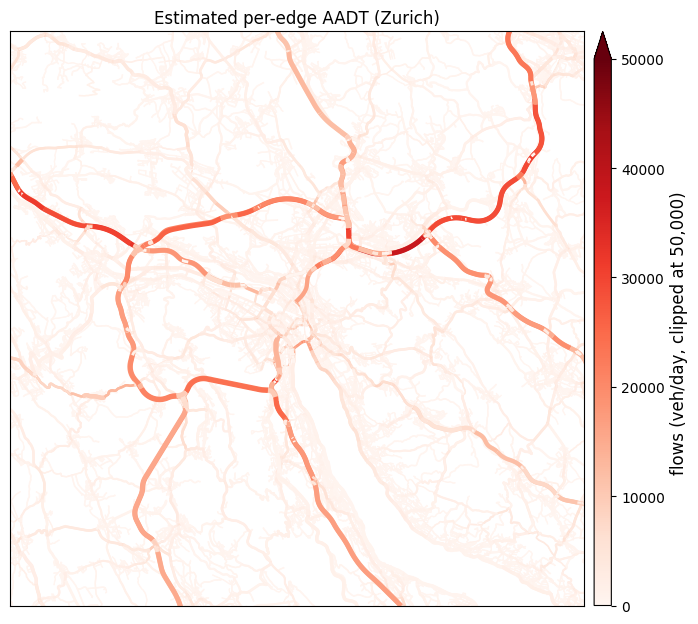

Calibrated edge speeds (km/h): median 22.0, P5–P95 [15.7, 43.0], max 86
Saved results/figures_highres/calibrated_edge_speed_map.png


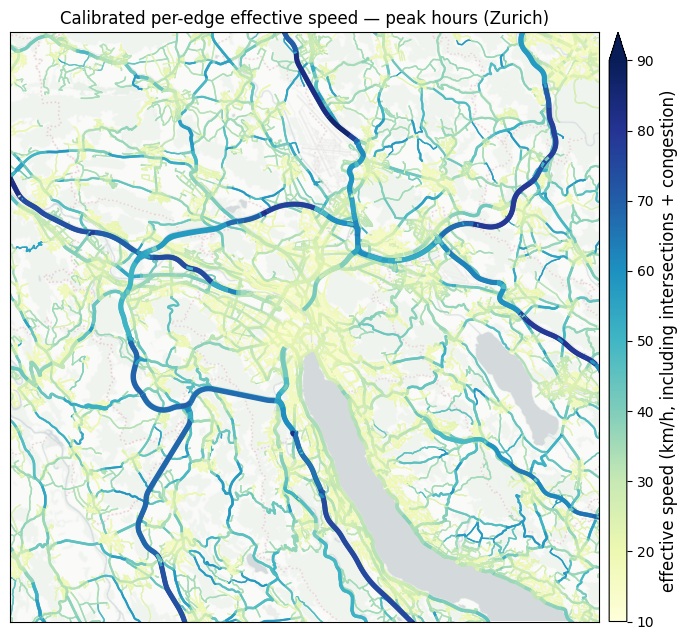

In [11]:
# 30 × 30 km crop centred on Zürich HB (2_683k / 1_248k in LV95).
PAPER_CROP_CENTER_XY = (2_683_000, 1_248_000)
PAPER_CROP_HALF_M    = 15_000
xlim = (PAPER_CROP_CENTER_XY[0] - PAPER_CROP_HALF_M,
        PAPER_CROP_CENTER_XY[0] + PAPER_CROP_HALF_M)
ylim = (PAPER_CROP_CENTER_XY[1] - PAPER_CROP_HALF_M,
        PAPER_CROP_CENTER_XY[1] + PAPER_CROP_HALF_M)

# --- Flow map.
FLOW_VMAX = 50_000   # AADT cap for the colour scale
fig, ax = plt.subplots(figsize=(7, 6.5))
figures.plot_network_map(
    ax, car_graph, flows,
    cbar_label=f'flows (veh/day, clipped at {FLOW_VMAX:,})',
    title=f'Estimated per-edge AADT ({LOCATION_LABEL})',
    xlim=xlim, ylim=ylim,
    vmax=FLOW_VMAX,
)
plt.tight_layout()
figures.save_figure(fig, 'flow_estimate_map')
plt.show()

# --- Calibrated per-edge effective speed. `speed_kph = length_m /
# duration_calibrated_s × 3.6`. Intersections + signalised crossings +
# congested corridors all appear as locally-slower edges even on roads
# that OSM tags as fast — the effect that makes `duration_calibrated`
# more realistic than the OSM-`maxspeed` baseline.
speed_calibrated_kph = {
    (u, v, k): float(d['length']) / float(d['duration_calibrated']) * 3.6
    for u, v, k, d in car_graph.edges(keys=True, data=True)
    if float(d['duration_calibrated']) > 0
}
_speeds = np.array(list(speed_calibrated_kph.values()))
print(f"Calibrated edge speeds (km/h): "
      f"median {np.median(_speeds):.1f}, "
      f"P5–P95 [{np.quantile(_speeds, 0.05):.1f}, "
      f"{np.quantile(_speeds, 0.95):.1f}], "
      f"max {_speeds.max():.0f}")

fig, ax = plt.subplots(figsize=(7, 6.5))
figures.plot_network_map(
    ax, car_graph, speed_calibrated_kph,
    cmap='YlGnBu', vmin=10, vmax=90,
    cbar_label='effective speed (km/h, including intersections + congestion)',
    title=f'Calibrated per-edge effective speed — peak hours ({LOCATION_LABEL})',
    xlim=xlim, ylim=ylim,
    basemap=True, crs=CRS_METRIC,
)
plt.tight_layout()
figures.save_figure(fig, 'calibrated_edge_speed_map')
plt.show()

## Downstream use — Pandana

[Pandana](https://github.com/UDST/pandana) is a fast C++ routing engine
widely used for cumulative-opportunity accessibility. Aperta and Pandana
can be used in a complementary fashion: aperta produces calibrated, congestion-aware,
multi-modal edge weights; Pandana consumes them for high-throughput
single-mode shortest-path queries on a fixed network.

This showcase doesn't save its output — the calibrated weights live
in-memory only — but persisting + reloading is trivial:

```python
import osmnx as ox
import pandana
import pandas as pd

# If you DO want to persist the calibrated graph:
# ox.save_graphml(car_graph, 'car_graph_calibrated.graphml')

nodes = ox.graph_to_gdfs(car_graph, edges=False)
edges = ox.graph_to_gdfs(car_graph, nodes=False).reset_index()

net = pandana.Network(
    node_x=nodes['x'], node_y=nodes['y'],
    edge_from=edges['u'], edge_to=edges['v'],
    edge_weights=edges[['duration_calibrated']],
)
net.set(pd.Series(supermarket_node_ids, index=supermarket_node_ids),
        name='supermarkets')
n_within_15min = net.aggregate(
    distance=15 * 60, type='count', name='supermarkets',
)
```

The same calibrated graph loads into NetworkX, igraph, r5py, and any
custom Dijkstra implementation. Calibration is a one-time step whose
product is a standard graph — downstream tooling is the caller's choice.

## What this notebook does NOT do

Beyond the no-stochastic-routing / no-capacity-slowdown simplifications
in the flow model:

- **No outer-loop tuning of the flow-model hyperparameters.**
  `DENSITY_INTERACTION_COEF`, `TRIPS_PER_BUILDING_PER_DAY`,
  `VC_BETA_EXPONENT`, cost bins, etc. shape the flow estimation
  (and, for `VC_BETA_EXPONENT`, the congestion feature that enters
  §5). §4 sweeps `DENSITY_INTERACTION_COEF` in isolation; the
  others are hand-picked. Production coordinate-descents
  them jointly with the linear calibration coefficients against
  counters + Google-Maps trip times.
- **No iterative refinement on stricter trip filters.** Production
  iterates filters (drop outliers, retain trips within a polygon,
  etc.) — we use a single set here.
- **No file outputs.** Both the calibrated graph and the flow estimates
  live in memory only. See the `ox.save_graphml(...)` example above
  if you want to persist.
- **No capacity-normalised stress map.** `vc_beta_2` enters the
  edge-weight fit as a feature; visualising it separately as a
  stress/pressure map is a natural next step. See `aperta-lumos` for
  a production example.

For a full production stack (scenario configs, typed I/O,
calibrate→transfer→apply dispatch, integrated calibrate → flows →
accessibility chain), see
[aperta-atlas](https://github.com/mmiotti/aperta-atlas).